In [1]:
import sys

In [2]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset

 cupy not imported 
2.2.1


In [3]:
N = 80
mult = 2*2
span = 2
x = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
y = np.sin(1*1*np.pi*x[:,0])*np.sin(3*1*np.pi*x[:,1])
xt = (np.random.rand(mult*N*N).reshape(-1,2)*2-1)*span/2.0
yt = np.sin(1*1*np.pi*xt[:,0])*np.sin(3*1*np.pi*xt[:,1])

In [4]:
print(x[:10,:])
print(y[:10])

[[ 0.48418316 -0.41578035]
 [-0.17253273  0.78957537]
 [-0.08578315 -0.89430158]
 [-0.46259895  0.89951042]
 [-0.97181386 -0.33964285]
 [ 0.40355226 -0.9758207 ]
 [ 0.60350458 -0.4827331 ]
 [ 0.49781241 -0.21366963]
 [ 0.16375359 -0.08569129]
 [-0.19098561 -0.32860817]]
[ 0.70031002 -0.472622    0.22348721 -0.80612368 -0.00525568 -0.21562581
  0.93507663 -0.90345167 -0.35558008  0.02513725]


In [5]:
xc = (x*128).astype('int8')
xtc = (x*128).astype('int8')
yc = np.sin(2*1*np.pi*xc[:,0]/128.)*np.sin(3*1*np.pi*xc[:,1]/128.)
ytc = np.sin(2*1*np.pi*xtc[:,0]/128.)*np.sin(3*1*np.pi*xtc[:,1]/128.)

In [6]:
print(xc[:10,:])
print(yc[:10])
print(np.sin(3*1*np.pi*xc[0,1]/128.))
print(np.sin(2*1*np.pi*xc[0,0]/128.))

[[  61  -53]
 [ -22  101]
 [ -10 -114]
 [ -59  115]
 [-124  -43]
 [  51 -124]
 [  77  -61]
 [  63  -27]
 [  20  -10]
 [ -24  -42]]
[ 0.10117661 -0.80626102  0.40433047 -0.1986569   0.00478776 -0.17292238
 -0.58122508 -0.04485815 -0.55838086  0.04533262]
0.6895405447370668
0.1467304744553618


In [7]:
print(np.max(xtc))
print(np.min(xtc))
print(np.max(xc))
print(np.min(xc))

127
-126
127
-126


In [8]:
class NeuralNet(): 
    
    def __init__(self, input_size, neurons_num):
        super().__init__()
        np.random.seed(0)
        self.params = {}
        self.cache = {}
        self.input_size = input_size
        self.neurons_num = neurons_num
        self.params = self.init(self.input_size, self.neurons_num)
        self.rng = np.random.default_rng()

    def init(self, input_size, neurons_numb):
        W0 = np.random.rand(neurons_numb,input_size)*2-1
        print(' this is W0 old ',W0.shape)
        scale = 1/max(1., (input_size+input_size)/2.)
        limit = math.sqrt(3.0 * scale)
        W0 = np.random.uniform(-limit, limit, size=(neurons_numb,input_size))
        print(' this is W0 new ',W0.shape)
        b0 = np.random.rand(neurons_numb,1)*2-1
        #b0 = np.zeros((neurons_numb,1))
        W1 = np.random.rand(1,neurons_numb)*.0001*(2-1) 
        b1 = np.zeros((1,1))
        return W0,b0,W1,b1

    def train(self, X_train, Y_train, epoch_num, batch_size=1, cost_fun='regression', lambd=2, X_val=None, Y_val=None):
        counter = 0
        m = X_train.shape[1]
        batch_numb = math.floor(m/batch_size)
        costs = []
        valcosts = []
        print(self.params)
        self.params = NeuralNet.cannonical_form(self.params)  
        ind = np.arange(m)
        
        for epoch in range(1,epoch_num+1):      # from 1 to epoch_num
            np.random.shuffle(ind)
            X_train = X_train[:,ind]
            Y_train = Y_train[:,ind]
            for j in range(batch_numb):    # go through batches
                x = X_train[:,j*batch_size:j*batch_size+batch_size]
                y = Y_train[:,j*batch_size:j*batch_size+batch_size]
                #print(' this is for batch ',x.shape,y.shape,j)
                y_hat, self.cache = NeuralNet.forward_pass(x,self.params,cost_fun)
                #print(y_hat)                
                grads = NeuralNet.back_pass(y, y_hat, cost_fun, self.cache)
                #print(grads)
                self.params = NeuralNet.update_params(self.params, grads, lambd, self.rng, False)
                self.params = NeuralNet.cannonical_form(self.params)                
                

            if (m % batch_size) != 0:       # the last batch may be of different size
                x = X_train[:,batch_numb*batch_size:]
                y = Y_train[:,batch_numb*batch_size:]
                #print(' this is last ',x.shape,y.shape,m)
                y_hat, self.cache = NeuralNet.forward_pass(x,self.params,cost_fun)
                #print(y_hat)
                grads = NeuralNet.back_pass(y, y_hat, cost_fun, self.cache)
                #print(grads)
                self.params = NeuralNet.update_params(self.params, grads, lambd, self.rng, False)
                self.params = NeuralNet.cannonical_form(self.params)                
           

            
            costs.append(NeuralNet.cost(y, y_hat, cost_fun))
            if not X_val.any()==None:
                yt_hat, _ = NeuralNet.forward_pass(X_val,self.params,cost_fun)
            
                valcosts.append(NeuralNet.cost(Y_val, yt_hat, cost_fun))

        
            #print("epoch: " + str(epoch) + "   cost: ", NeuralNet.cost(y, y_hat, cost_fun))
        return costs, valcosts

    @staticmethod
    def linear(x,w,b):
        Z = np.dot(w,x)+b   
        return Z
        
    @staticmethod
    def sigmoid(z):
        a = 1/(1+np.exp(-z))
        return a    

    @staticmethod
    def relu(z):
        a = np.array(z, copy=True)
        a[a<0]=0
        return a    

    @staticmethod
    def linear_back(dZ,w,x):
        m = x.shape[1]
        dx = np.dot(w.T,dZ)
        dw = (1./m)*np.dot(dZ,x.T)
        db = (1./m)*np.sum(dZ, axis = 1, keepdims=True) 
        return dx,dw,db


    @staticmethod
    def cannonical_form(params):
        W0,b0,W1,b1 = params
        wh1, wn1 = bounds.nn_wnorm(W0.T)
        #print(wh1,wn1)
        #wn1 += 0.000000001
        nW0 = (wh1.T*128).astype('float').astype('float')/128.
        #print(' this is the where ',np.where(~(wh1.T*128).astype('int').any(axis=1))[0])
        #print(' this is the int ',(wh1.T*128).astype('int'))
        nb0 = ((b0/wn1.reshape(-1,1))*128).astype('float').astype('float')/128.
        nW1 = (W1*wn1.reshape(1,-1))
        nb1 = b1
        return nW0,nb0,nW1,nb1

    @staticmethod
    def relu_back(da, a):
        dz = np.array(da, copy=True)
        #dz[a>0]=1 is not necessary,  1 * a so de facto a
        dz[a<=0]=0
        return dz

    @staticmethod
    def sigmoid_back(da, a):
        dz = da*a*(1-a)
        return dz

    @staticmethod
    def forward_pass(X, params,cost_fun):    
        W0,b0,W1,b1 = params    
        z1 = NeuralNet.linear(X,W0,b0)
        cache = {}
        cache["X"] = X
        cache["W0"] = W0
        cache["b0"] = b0
        cache["z1"] = z1 
        a1 = NeuralNet.relu(z1)
        cache["a1"] = a1
        cache["W1"] = W1    
        z2 = NeuralNet.linear(a1,W1,b1)
        cache["z2"] = z2
        if cost_fun=='regression':
            y_hat = z2
        else:
            y_hat = NeuralNet.sigmoid(z2)    
        return y_hat, cache

    @staticmethod
    def back_pass(y, y_hat, cost_fun, cache):  
        m = y.shape[1]
        if cost_fun == 'cross_entropy': 
            dy_hat = (1./m)*(-(y/y_hat)+((1-y)/(1-y_hat)) )
            dz2 = NeuralNet.sigmoid_back(dy_hat, y_hat)             
        if cost_fun == 'quadratic':
            dy_hat = (1./m)*(y_hat - y)
            dz2 = NeuralNet.sigmoid_back(dy_hat, y_hat)             
        if cost_fun == 'regression':
            dy_hat = (1./m)*(y_hat - y)            
            dz2=dy_hat
        da1, dw1, db1 = NeuralNet.linear_back(dz2,cache["W1"],cache["a1"])
        dz1 = NeuralNet.relu_back(da1,cache["a1"])
        _, dw0, db0 = NeuralNet.linear_back(dz1,cache["W0"],cache["X"])    
        return dw0, db0, dw1, db1

    @staticmethod
    def update_params(params, grads, lambd, rng, debug=False):
        W0,b0,W1,b1 = params
        dw0, db0, dw1, db1 = grads
        if debug:
            print(rng.random(dw0.shape))
            print(' this is the delta for dw0',dw0)
            #print(' this is the delta for dw0',rng.random(dw0.shape)<np.abs(dw0)*128*lambd)            
            print(' this is the delta for dw1',dw1)
        W0 = W0 - lambd*dw0
        b0 = b0 - lambd*db0
        W1 = W1 - lambd*dw1
        b1 = b1 - lambd*db1
        return W0,b0,W1,b1

    @staticmethod    
    def cost(y,y_hat, cost_fun):
        m = y.shape[1]
        if cost_fun == 'cross_entropy':
            cost = -(1./m)*np.sum( np.dot(y,np.log(y_hat).T) + np.dot(1-y,np.log(1-y_hat).T) )
        if cost_fun == 'quadratic':
            cost = (1./(2*m))*np.sum(np.power(y_hat-y,2))    
        if cost_fun == 'regression':
            cost = (1./(2*m))*np.sum(np.power(y_hat-y,2))
        return cost

In [9]:
nn = NeuralNet(2,400)

 this is W0 old  (400, 2)
 this is W0 new  (400, 2)


In [10]:
print(x.shape)
print(y.shape)
costs, valcosts = nn.train(x.T, y.reshape(-1,1).T, epoch_num=400, batch_size=80, lambd=.2, X_val=xt.T, Y_val=yt.reshape(-1,1).T)


(160, 2)
(160,)
(array([[-1.12678291,  0.34220622],
       [-0.22461109, -0.30029134],
       [ 0.75778632,  0.51203022],
       [ 1.11288602, -0.36268066],
       [ 0.97377692,  0.66128185],
       [-0.34923685,  0.29801824],
       [-0.51789572,  0.91708876],
       [-0.94935531, -0.70438908],
       [-0.7764067 , -0.23753681],
       [ 0.60069562,  0.06590952],
       [-0.03018672, -1.22340754],
       [-0.18272771, -1.06907055],
       [-0.71463067,  1.05914452],
       [-0.69712918,  0.87774437],
       [ 0.74193421, -0.8349178 ],
       [ 0.25894036, -0.9414323 ],
       [ 0.55820971,  0.33671244],
       [ 0.76409031, -0.05049733],
       [ 1.01620288, -1.10386513],
       [-0.50731734,  0.52676913],
       [-0.20059065, -0.8011023 ],
       [-0.96213325,  0.7773189 ],
       [-0.065786  ,  0.93639993],
       [ 0.57143934, -0.22112473],
       [-0.30983347,  0.03830597],
       [ 0.95299836,  0.58121145],
       [-1.21212274,  0.47558767],
       [ 1.02757909,  0.51550922],
   

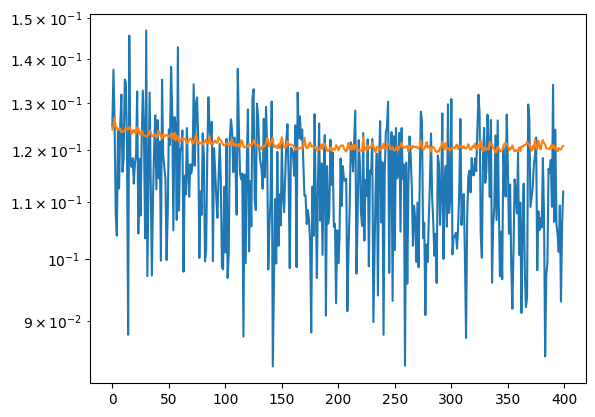

In [11]:
plt.plot(costs)
plt.plot(valcosts)
plt.yscale('log')

In [12]:
print(nn.params)
print(nn.params[0])

(array([[-0.76704559,  0.23295441],
       [-0.42793659, -0.57206341],
       [ 0.59670073,  0.40329927],
       [ 0.75420889, -0.24579111],
       [ 0.59555784,  0.40444216],
       [-0.539566  ,  0.460434  ],
       [-0.36103662,  0.63896338],
       [-0.57404308, -0.42595692],
       [-0.76568525, -0.23431475],
       [ 0.90112658,  0.09887342],
       [-0.02405217, -0.97594783],
       [-0.14599024, -0.85400976],
       [-0.40307726,  0.59692274],
       [-0.44281829,  0.55718171],
       [ 0.4706253 , -0.5293747 ],
       [ 0.2157297 , -0.7842703 ],
       [ 0.62375242,  0.37624758],
       [ 0.93800871, -0.06199129],
       [ 0.47932587, -0.52067413],
       [-0.49059481,  0.50940519],
       [-0.20027895, -0.79972105],
       [-0.55319111,  0.44680889],
       [-0.06572889,  0.93427111],
       [ 0.7209722 , -0.2790278 ],
       [-0.88996936,  0.11003064],
       [ 0.62115677,  0.37884323],
       [-0.71819824,  0.28180176],
       [ 0.66590565,  0.33409435],
       [-0.95145466

(2, 400)
(400,)
(400, 2)
[-1.98049150e-03  7.25110955e-03  5.10415899e-03  4.41615889e-04
  5.23299317e-04  1.38475910e-04 -8.02083425e-03  3.32421467e-03
  2.05180317e-03 -7.84584336e-04  4.16239387e-03  3.01462772e-03
 -1.06797411e-02 -1.22993312e-02 -1.34909180e-02 -4.52482057e-03
 -5.21125066e-04  5.91588802e-05 -1.00792016e-02  7.05253106e-04
  4.76273601e-03 -1.33446549e-02 -2.14494754e-03 -8.63708929e-03
  2.42667103e-03  1.30758039e-03 -2.02450485e-03  8.12229514e-03
  1.80192540e-03  1.61213658e-03  9.53834024e-03  1.99467175e-03
  4.04536246e-03 -1.98097340e-05 -8.40345151e-03 -1.67131568e-02
 -5.07821182e-03  3.11191636e-05  2.98684913e-03  3.81613559e-03
 -4.79458571e-03  4.16080848e-03 -1.69232454e-02  7.98918659e-03
 -9.07580131e-03  5.40646156e-03  1.88417021e-03  8.66355245e-06
  6.28260375e-04  3.70510630e-06 -6.50947856e-03  6.92846913e-03
  8.58041916e-03  9.56199330e-03  1.06844962e-02 -1.37764346e-02
 -5.10413789e-03 -2.97352246e-03  1.72256966e-03  5.89254487e-04


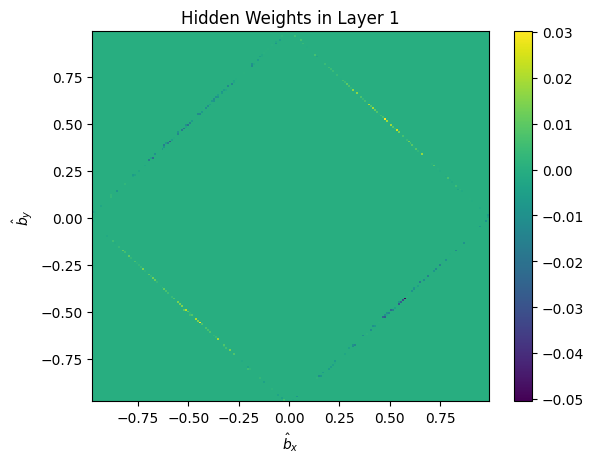

In [13]:
wh1, wn1 = bounds.nn_wnorm(nn.params[0].T)
print(wh1.shape)
print(wn1.shape)
print(nn.params[0].shape)
print(nn.params[2][0]*wn1)
hinfo, xedge, yedge , _ = plt.hist2d(wh1.T[:,0], wh1.T[:,1], bins=200, weights=nn.params[2][0]*wn1)
plt.title('Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$\hat{b}_y$')
plt.colorbar()

[[-0.19218255  0.32354206 -0.10127066 ... -0.04443462 -0.19722345
   0.19294601]]


Text(0, 0.5, 'y')

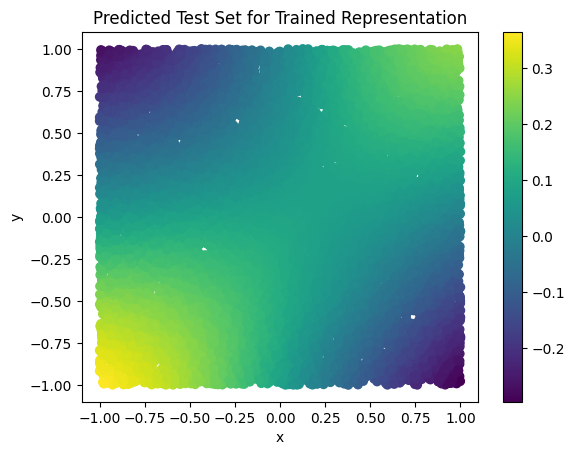

In [14]:
ref = NeuralNet.forward_pass(xt.T, nn.params,'regression')
print(ref[0])
plt.scatter(xt[:,0], xt[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Trained Representation')
plt.xlabel('x')
plt.ylabel('y')

[[-0.19218255  0.32354206 -0.10127066 ... -0.04443462 -0.19722345
   0.19294601]]


Text(0, 0.5, 'y')

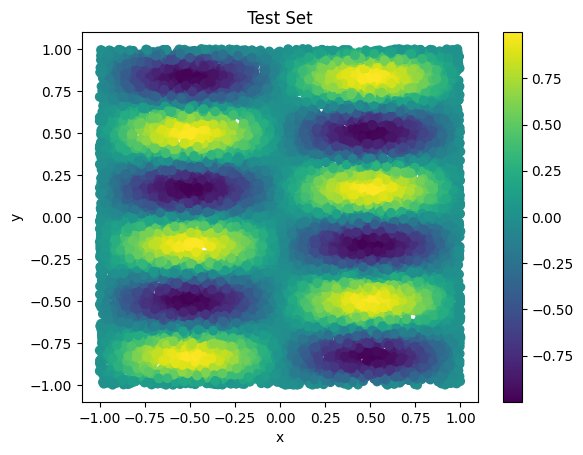

In [15]:
ref = NeuralNet.forward_pass(xt.T, nn.params,'regression')
print(ref[0])
plt.scatter(xt[:,0], xt[:,1], c=yt)
plt.colorbar()
plt.title(' Test Set ')
plt.xlabel('x')
plt.ylabel('y')

In [16]:
ref[1]

{'X': array([[-0.88697858, -0.833163  , -0.77905799, ...,  0.35908894,
         -0.77255933, -0.31577494],
        [ 0.76669988, -0.86152397,  0.51749085, ..., -0.83147412,
          0.84612218, -0.62209041]]),
 'W0': array([[-0.76704559,  0.23295441],
        [-0.42793659, -0.57206341],
        [ 0.59670073,  0.40329927],
        [ 0.75420889, -0.24579111],
        [ 0.59555784,  0.40444216],
        [-0.539566  ,  0.460434  ],
        [-0.36103662,  0.63896338],
        [-0.57404308, -0.42595692],
        [-0.76568525, -0.23431475],
        [ 0.90112658,  0.09887342],
        [-0.02405217, -0.97594783],
        [-0.14599024, -0.85400976],
        [-0.40307726,  0.59692274],
        [-0.44281829,  0.55718171],
        [ 0.4706253 , -0.5293747 ],
        [ 0.2157297 , -0.7842703 ],
        [ 0.62375242,  0.37624758],
        [ 0.93800871, -0.06199129],
        [ 0.47932587, -0.52067413],
        [-0.49059481,  0.50940519],
        [-0.20027895, -0.79972105],
        [-0.55319111,  0.44

In [17]:
NeuralNet.back_pass(yt.reshape(1,-1), ref[0], 'regression', ref[1])

(array([[ 1.07170600e-09,  1.58388756e-09],
        [-6.17115177e-09, -9.64737377e-09],
        [ 2.73536016e-09, -1.48985306e-10],
        [-2.86392191e-10, -3.51062426e-10],
        [ 4.19872222e-11, -3.27187580e-10],
        [ 6.14898847e-12, -6.05396161e-12],
        [ 9.32812140e-09,  5.86023450e-09],
        [-3.01464299e-09, -1.00190100e-09],
        [-1.67856655e-09, -1.98557929e-09],
        [ 4.61421354e-10,  6.39723512e-10],
        [-1.00530912e-08, -4.94348164e-09],
        [-3.49789430e-09, -3.11540323e-09],
        [ 6.90301202e-09,  2.27616641e-09],
        [ 8.59860392e-09,  3.96925203e-09],
        [-2.51646554e-09,  6.25797477e-09],
        [-2.74077565e-10,  9.02035265e-09],
        [ 3.01338492e-10,  4.19210671e-10],
        [ 0.00000000e+00,  0.00000000e+00],
        [-1.16205588e-09,  3.49189818e-09],
        [-5.36301214e-11,  9.34830505e-11],
        [ 1.46158100e-09,  1.84548747e-10],
        [ 1.00723011e-08,  2.22602155e-09],
        [ 1.33328378e-09, -1.092

In [18]:
print(nn.params[0].shape)
print(nn.params[1].shape)
print(nn.params[2].shape)
print(nn.params[3].shape)
print(wn1.reshape(-1,1).shape)
print((nn.params[1]/wn1.reshape(-1,1)).shape)

(400, 2)
(400, 1)
(1, 400)
(1, 1)
(400, 1)
(400, 1)


(1, 12800)


Text(0, 0.5, 'y')

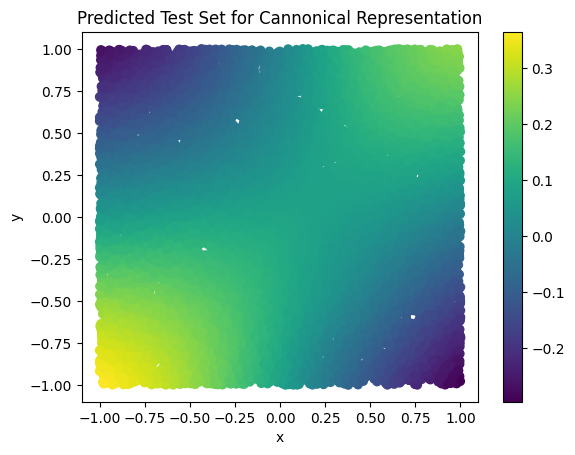

In [19]:
ref = NeuralNet.forward_pass(xt.T, (wh1.T,(nn.params[1]/wn1.reshape(-1,1)),(nn.params[2]*wn1.reshape(1,-1)),nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xt[:,0], xt[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')

In [20]:
print(((nn.params[1]/wn1.reshape(-1,1))*256).astype('int').astype('float').T)
print(((nn.params[1]/wn1.reshape(-1,1))*256).T)
print(np.max(((nn.params[1]/wn1.reshape(-1,1))*256)))
print(np.max((wh1.T/128*256)))
print((wh1.T/128*512))
print((wh1.T/128))
print((wh1.T))
print((wh1.T*128))

[[ 1.460e+02 -8.600e+01 -7.800e+01  1.530e+02  1.530e+02 -2.380e+02
   5.500e+01 -1.210e+02  7.600e+01  2.510e+02  7.500e+01 -3.300e+01
  -3.300e+01 -3.400e+01  2.900e+01  1.620e+02  2.450e+02 -2.800e+02
  -7.600e+01 -1.910e+02 -1.560e+02 -4.500e+01  3.000e+00  8.300e+01
   3.410e+02  1.300e+02  1.480e+02  5.300e+01  2.120e+02  1.160e+02
  -4.600e+01  2.080e+02 -1.690e+02 -1.750e+02 -1.230e+02 -1.100e+01
   1.400e+02 -3.510e+02  1.720e+02  9.700e+01 -1.500e+02 -4.900e+01
   9.000e+00 -1.900e+01  8.600e+01  1.331e+03  5.230e+02 -7.170e+02
   1.280e+02 -4.980e+02 -1.190e+02 -9.900e+01 -7.900e+01  1.000e+01
   5.000e+01 -7.000e+00  1.080e+02 -1.260e+02  1.890e+02  1.740e+02
   7.400e+01 -2.100e+01  5.200e+01 -2.100e+01  2.000e+01 -2.000e+01
  -3.600e+01  1.180e+02 -1.540e+02 -1.440e+02  1.160e+02  8.800e+01
  -1.550e+02 -6.600e+01  1.630e+02  8.700e+01  4.300e+01 -1.220e+02
  -2.261e+03 -1.900e+01  8.900e+01  1.590e+02  2.040e+02 -3.940e+02
  -6.500e+01 -6.000e+01 -1.460e+02  7.800e+01  2

(1, 160)


Text(0, 0.5, 'y')

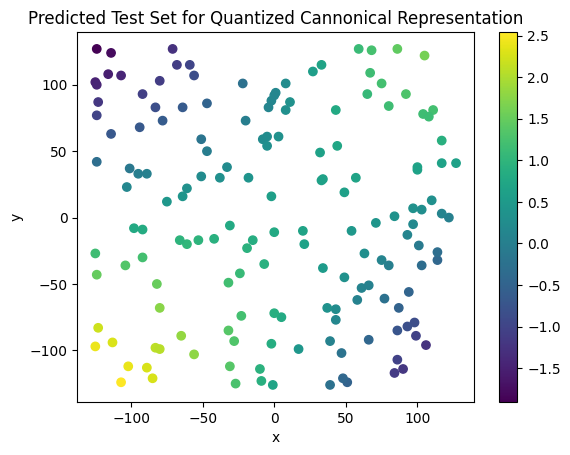

In [21]:
ref = NeuralNet.forward_pass(xtc.T, ((wh1.T/128*2048).astype('int').astype('float'),((nn.params[1]/wn1.reshape(-1,1))*2048).astype('int').astype('float'),(nn.params[2]*wn1.reshape(1,-1))/256,nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xtc[:,0], xtc[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Quantized Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')

(1, 160)


Text(0, 0.5, 'y')

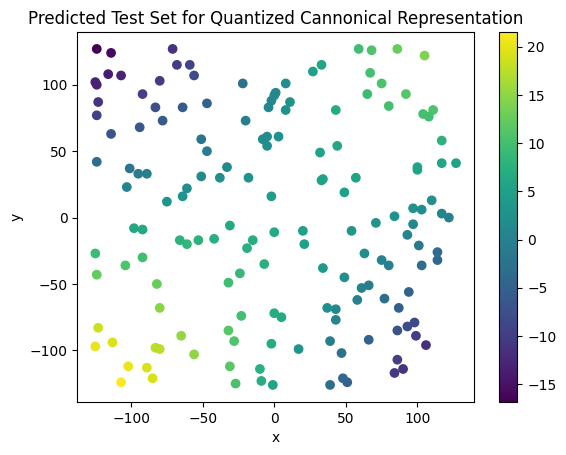

In [22]:
ref = NeuralNet.forward_pass(xtc.T, ((wh1.T*128).astype('int').astype('float'),((nn.params[1]/wn1.reshape(-1,1))*128*128).astype('int').astype('float'),(nn.params[2]*wn1.reshape(1,-1))/256,nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xtc[:,0], xtc[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Quantized Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')

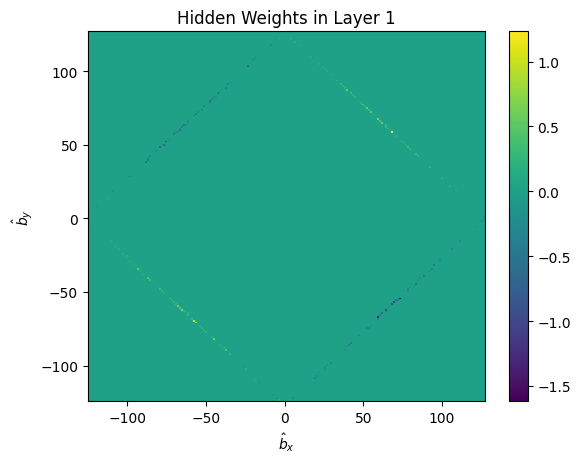

In [23]:
hinfo, xedge, yedge , _ = plt.hist2d((wh1.T[:,0]*128).astype('int8'), (wh1.T[:,1]*128).astype('int8'), bins=200, weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$\hat{b}_y$')
plt.colorbar()

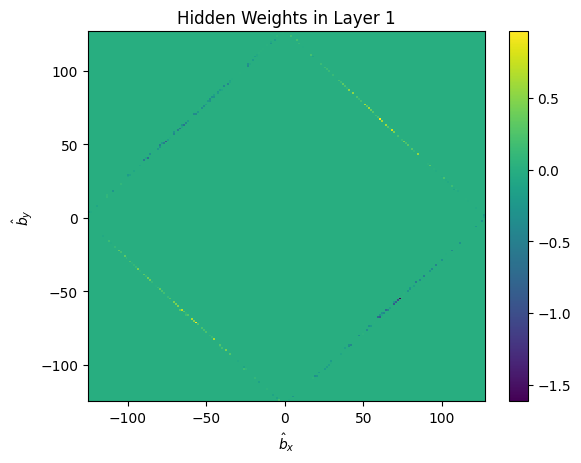

In [24]:
hinfo, xedge, yedge , _ = plt.hist2d((wh1.T[:,0]*128), (wh1.T[:,1]*128), bins=200, weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$\hat{b}_y$')
plt.colorbar()

(400, 1)
(400,)
(400, 1)
(400,)


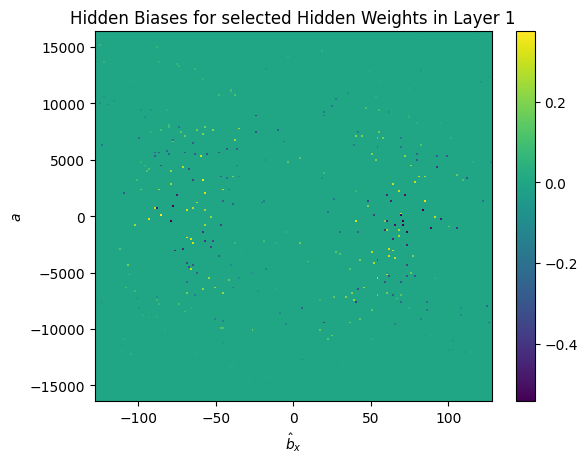

In [25]:
mbias = ((nn.params[1]/wn1.reshape(-1,1))*128*128)
print(mbias.shape)
print((wh1.T[:,0]*128).shape)
print((wh1.T[:,0]*128).reshape(-1,1).shape)
print((nn.params[2][0]*wn1).shape)
hinfoB, xedgeB, yedgeB , _ = plt.hist2d((wh1.T[:,0]*128), mbias.flatten(), bins=200, range=[[-128,128],[-128*128,128*128]], weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Biases for selected Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$a$')
plt.colorbar()

(400, 1)
(400,)
(400, 1)
(400,)


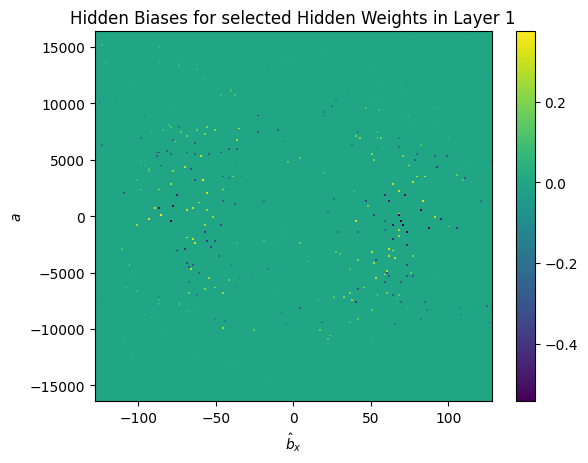

In [26]:
mbias = ((nn.params[1]/wn1.reshape(-1,1))*128*128)
print(mbias.shape)
print((wh1.T[:,0]*128).shape)
print((wh1.T[:,0]*128).reshape(-1,1).shape)
print((nn.params[2][0]*wn1).shape)
hinfoB, xedgeB, yedgeB , _ = plt.hist2d((wh1.T[:,0]*128).astype('int'), mbias.flatten().astype('int'), bins=200, range=[[-128,128],[-128*128,128*128]], weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Biases for selected Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$a$')
plt.colorbar()

In [27]:
qparams = {}
wparams = {}
for i in range(wh1.T.shape[0]):
    #qp = tuple(list((wh1.T[i,:]*128).astype('int'))+list(((nn.params[1]/wn1.reshape(-1,1))*128*128).reshape(-1,1).astype('int')[i]))
    #print(qp)
    qp = tuple((wh1.T[i,:]*32).astype('int'))
    twh1 = tuple((wh1.T[i,:]*32).astype('int'))
    #print(twh1)
    if not twh1 in wparams:
        wparams[twh1]=(nn.params[2][0][i]*wn1[i])
    else:
        wparams[twh1]+=(nn.params[2][0][i]*wn1[i])
    if not qp in qparams:
        qparams[qp]=[]
        qparams[qp].append([nn.params[2][0][i]*wn1[i],((nn.params[1]/wn1.reshape(-1,1))*32*32).reshape(-1,1).astype('int')[i][0]])
    else:
        qparams[qp].append([nn.params[2][0][i]*wn1[i],((nn.params[1]/wn1.reshape(-1,1))*32*32).reshape(-1,1).astype('int')[i][0]])        
print(len(qparams))
print(len(wparams))

115
115


In [28]:
print(qparams)

{(-24, 7): [[-0.001980491496597624, 584], [-0.0029165725687322996, -451], [-0.0014096051063603682, -504], [-0.006486435134678194, 432]], (-13, -18): [[0.007251109545906128, -344], [0.0070344251722999195, -9]], (19, 12): [[0.005104158991289816, -314], [0.0005232993174453212, 614], [-0.0005211250656859247, 981], [0.001307580393704344, 520], [0.009248207575327422, 184], [0.006130255009201185, -221]], (24, -7): [[0.0004416158892294019, 614], [-0.009209225177613125, 335], [-0.00014286474875619299, 1160]], (-17, 14): [[0.0001384759099718816, -952], [-0.013344654893644867, -180], [-0.01023361682862433, -263], [-0.008475784795145191, 349]], (-11, 20): [[-0.008020834247284246, 223], [-0.004789909645391733, -576], [-0.00893747199155968, 351], [-0.0109621604893745, -42], [-0.0013066727638170739, -697], [-0.008420442342879154, 91]], (-18, -13): [[0.0033242146703415304, -487], [0.001994671750301276, 832], [-1.980973404020703e-05, -701], [0.0044767130699565035, 464], [0.0019623052371491676, 848]], (

In [29]:
print(wparams)

{(-24, 7): -0.012793104306368486, (-13, -18): 0.014285534718206047, (19, 12): 0.021792376221282165, (24, -7): -0.008910474037139918, (-17, 14): -0.031915580607442505, (-11, 20): -0.042437491480306386, (-18, -13): 0.011738094993708271, (-24, -7): 0.008065759467876977, (28, 3): 0.00029350004080899283, (0, -31): 0.0049454707993406375, (-4, -27): -0.0013928919735149425, (-12, 19): -0.02204768578916735, (-14, 17): -0.02447719627410476, (15, -16): -0.07622499175780294, (6, -25): -0.015741334218604193, (30, -1): -0.006729564181350216, (-15, 16): -0.019812757439484883, (-6, -25): 0.003196499920793776, (-2, 29): -0.00919558560317183, (23, -8): -0.034931644207849596, (-28, 3): 0.004653064942248148, (-22, 9): -0.01897580702203712, (21, 10): 0.017254866841138795, (-30, -1): -5.717120874365773e-06, (-22, -9): 0.010862518464652984, (16, 15): 0.030931376797107345, (5, 26): 0.004045362455550128, (31, 0): -0.01866269868564895, (17, -14): -0.07850808770253155, (5, -26): -0.013603177992278122, (-10, -21)

In [30]:
slw = sorted(wparams.items(),key=lambda item: abs(item[1]))
print(slw[-1])
topres= []
for s in slw:
    if abs(s[1])>0.03*abs(slw[-1][1]):
        topres.append(s[0])
print(topres)
print(len(topres))

((17, -14), -0.07850808770253155)
[(-26, 5), (8, -23), (-23, 8), (-29, 2), (-6, -25), (27, 4), (2, 29), (7, 24), (4, 27), (25, 6), (26, 5), (5, 26), (-1, 30), (-20, -11), (-28, 3), (9, -22), (0, -31), (8, 23), (30, -1), (-27, -4), (-8, 23), (-31, 0), (-1, -30), (1, -30), (-4, 27), (7, -24), (-20, 11), (-8, -23), (-24, -7), (-27, 4), (14, 17), (24, -7), (14, -17), (-2, 29), (23, 8), (27, -4), (4, -27), (-26, -5), (11, -20), (-10, -21), (-22, -9), (11, 20), (1, 30), (18, 13), (20, 11), (-18, -13), (26, -5), (21, -10), (-24, 7), (6, 25), (-12, -19), (5, -26), (-13, -18), (-15, -16), (22, -9), (6, -25), (-13, 18), (19, -12), (21, 10), (-25, -6), (31, 0), (-22, 9), (-9, -22), (-15, 16), (-23, -8), (19, 12), (-12, 19), (-19, -12), (9, 22), (-10, 21), (-14, 17), (12, 19), (-9, 22), (-11, -20), (13, -18), (-5, 26), (20, -11), (-21, -10), (16, 15), (-17, 14), (10, 21), (-18, 13), (-21, 10), (23, -8), (10, -21), (-17, -14), (-11, 20), (16, -15), (13, 18), (17, 14), (-16, -15), (-19, 12), (15, 16

In [31]:
filter(lambda x: x in topres ,(wh1.T*32).astype('int'))
print((wh1.T*32).astype('int')[0])
print(tuple((wh1.T*32).astype('int')[0]) in topres)

[-24   7]
True


In [32]:
inds = [i for i,x in enumerate((wh1.T*32).astype('int')) if tuple(x) in topres]
print((wh1.T*32).astype('int').astype('float')[inds,:].shape)
print(((nn.params[1]/wn1.reshape(-1,1))*32*32).astype('int').astype('float')[inds,:].shape)
print((nn.params[2]*wn1.reshape(1,-1))[:,inds].shape)

(377, 2)
(377, 1)
(1, 377)


(1, 160)


Text(0, 0.5, 'y')

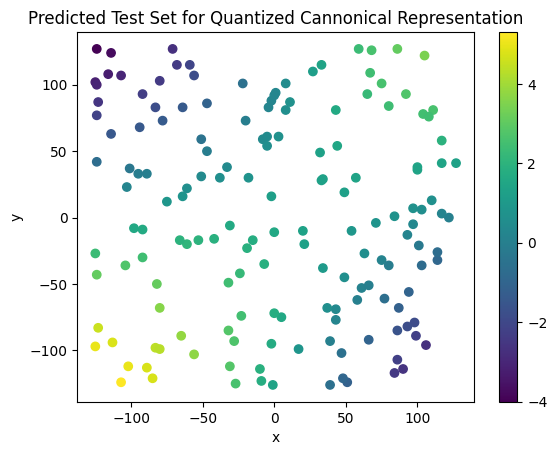

In [33]:
ref = NeuralNet.forward_pass(xtc.T, ((wh1.T*32).astype('int').astype('float')[inds,:],((nn.params[1]/wn1.reshape(-1,1))*32*128).astype('int').astype('float')[inds,:],(nn.params[2]*wn1.reshape(1,-1))[:,inds]/256,nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xtc[:,0], xtc[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Quantized Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')